NB: this notebook is a mess but runs were too computationally expensive to give it a proper clean-up.

In [49]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedShuffleSplit

from sklearn.multiclass import OneVsRestClassifier
from scipy.special import softmax

from sklearn.svm import LinearSVC, SVC


from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score,
    PrecisionRecallDisplay
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder
from collections import Counter
from sklearn.dummy import DummyClassifier

from collections import defaultdict

In [50]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [51]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [52]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

In [53]:
# Define target variables

y_train_rating = df_train['rating']
y_test_rating = df_test['rating']

y_train_titleType = df_train['titleType']
y_test_titleType = df_test['titleType']

In [54]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [55]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

# Pre-processing

In [56]:
# drop target variables
df_train.drop(columns=['rating', 'averageRating'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwards', 'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [57]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
#cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions','rating']).index #drop the target var and lists
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [58]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [59]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

Consistently w/ Logistic Regression, we keep the top 25 countries and regions, aggregating the rest into an 'Other' category.

In [60]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [61]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 25
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [62]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 25
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [63]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        """Return feature names for output features"""
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [64]:
def build_preprocessor(num_cols, bool_cols, cat_cols, scaler_type='robust'):
    if scaler_type == 'power':
        scaler = PowerTransformer()
    else:  # default to RobustScaler
        scaler = RobustScaler()
    
    return ColumnTransformer(
        transformers=[
            ('num', scaler, num_cols),
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

Let's use a 5-fold cross validation to choose which scaler to use.
We'll use RobustScaler, though the difference is negligible.

In [74]:
# Create pipelines with different scalers
pipeline_power = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols, 'power')),
    ('clf', LinearSVC(random_state=42, max_iter=5000))
])

pipeline_robust = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols, 'robust')),
    ('clf', LinearSVC(random_state=42, max_iter=5000))
])

# 5-fold cross-validation
cv_folds = 5

print("Comparing PowerTransformer vs RobustScaler with 5-fold CV:")
print("=" * 60)

# Test PowerTransformer
print("\nPowerTransformer:")
scores_power = cross_val_score(pipeline_power, df_train, y_train_rating, 
                              cv=cv_folds, scoring='f1_macro', n_jobs=-1)
print(f"F1-macro scores: {scores_power}")
print(f"Mean F1-macro: {scores_power.mean():.4f} (+/- {scores_power.std() * 2:.4f})")

# Test RobustScaler
print("\nRobustScaler:")
scores_robust = cross_val_score(pipeline_robust, df_train, y_train_rating, 
                               cv=cv_folds, scoring='f1_macro', n_jobs=-1)
print(f"F1-macro scores: {scores_robust}")
print(f"Mean F1-macro: {scores_robust.mean():.4f} (+/- {scores_robust.std() * 2:.4f})")

# Compare results
print("\n" + "=" * 60)
print("COMPARISON:")
diff = scores_power.mean() - scores_robust.mean()
if abs(diff) < 0.001:
    print(f"Results are very similar (difference: {diff:.5f})")
elif diff > 0:
    print(f"PowerTransformer performs better by {diff:.4f}")
else:
    print(f"RobustScaler performs better by {abs(diff):.4f}")

print(f"\nPowerTransformer CV mean: {scores_power.mean():.4f}")
print(f"RobustScaler CV mean:     {scores_robust.mean():.4f}")

Comparing PowerTransformer vs RobustScaler with 5-fold CV:

PowerTransformer:
F1-macro scores: [0.11890806 0.11608308 0.11788811 0.11581506 0.11854549]
Mean F1-macro: 0.1174 (+/- 0.0025)

RobustScaler:
F1-macro scores: [0.11938777 0.11672317 0.1180623  0.11660662 0.1192761 ]
Mean F1-macro: 0.1180 (+/- 0.0024)

COMPARISON:
Results are very similar (difference: -0.00056)

PowerTransformer CV mean: 0.1174
RobustScaler CV mean:     0.1180


# Rating
- We start with a LinearSVC → GridSearch 
- Then Non-Linear SVC → RandomizedSearch

In [75]:
#DUMMY CLASSIFIER

dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(df_train, y_train_rating)  
dummy_predictions = dummy_clf.predict(df_test)

print(classification_report(y_test_rating, dummy_predictions))


              precision    recall  f1-score   support

      (0, 1]       0.00      0.00      0.00        22
      (1, 2]       0.00      0.00      0.00       133
      (2, 3]       0.01      0.01      0.01       374
      (3, 4]       0.03      0.03      0.03      1035
      (4, 5]       0.06      0.06      0.06      2750
      (5, 6]       0.14      0.14      0.14      6270
      (6, 7]       0.27      0.27      0.27     11750
      (7, 8]       0.32      0.32      0.32     14613
      (8, 9]       0.14      0.14      0.14      6591
     (9, 10]       0.03      0.03      0.03      1319

    accuracy                           0.22     44857
   macro avg       0.10      0.10      0.10     44857
weighted avg       0.22      0.22      0.22     44857



## LinearSVC

In [76]:
pipeline = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LinearSVC(random_state=42, max_iter=5000))
    ], verbose=True)


In [77]:
""""
linear_svm_param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__loss': ['hinge', 'squared_hinge'],
    'clf__dual': [False],  # Set to False for n_samples > n_features
    'clf__max_iter': [5000]  # Increase to ensure convergence
    
}
"""

In [78]:
param_grid = [
    # L1 and L2 penalty (only with squared_hinge loss)
    {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l1', 'l2'],
        'clf__loss': ['squared_hinge'],
        #'clf__dual': [False],  # the ideal value for dual will be automatically set → default auto
        'clf__max_iter': [5000],
        'clf__class_weight': [None, 'balanced']
    },
    # L2 penalty with hinge loss (dual=True automatically)
    {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__loss': ['hinge'],
        'clf__max_iter': [5000],
        'clf__class_weight': [None, 'balanced']
    },
]

In [79]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(df_train, y_train_rating)

print(f"Best score: {grid_search.best_score_:.3f}; vs train score: {grid_search.best_estimator_.score(df_train, y_train_rating):.3f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.4s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  10.2s
Best score: 0.158; vs train score: 0.275
Best parameters: {'clf__C': 0.001, 'clf__class_weight': 'balanced', 'clf__loss': 'squared_hinge', 'clf__max_iter': 5000, 'clf__penalty': 'l2'}


In [80]:
linearsvc_rating_model = grid_search.best_estimator_
joblib.dump(linearsvc_rating_model, data_dir/"linearsvc_rating_model.pkl")

['..\\..\\results\\linearsvc_rating_model.pkl']

In [81]:
y_pred_rating = linearsvc_rating_model.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.003     0.591     0.005        22
      (1, 2]      0.011     0.256     0.020       133
      (2, 3]      0.030     0.136     0.050       374
      (3, 4]      0.085     0.169     0.113      1035
      (4, 5]      0.196     0.225     0.209      2750
      (5, 6]      0.306     0.224     0.259      6270
      (6, 7]      0.399     0.147     0.215     11750
      (7, 8]      0.487     0.505     0.496     14613
      (8, 9]      0.262     0.041     0.072      6591
     (9, 10]      0.092     0.334     0.145      1319

    accuracy                          0.270     44857
   macro avg      0.187     0.263     0.158     44857
weighted avg      0.361     0.270     0.285     44857



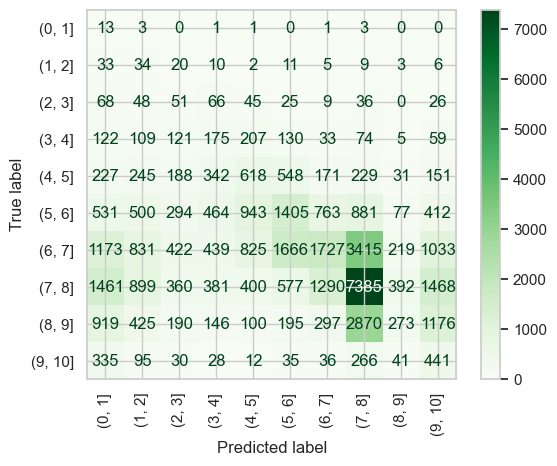

In [82]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

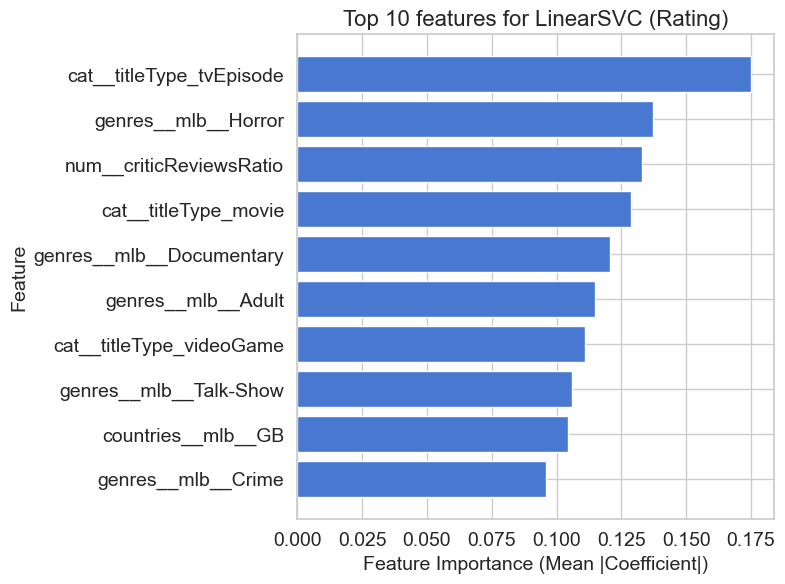

In [83]:
# Get feature importance from LinearSVC coefficients
svm_clf = linearsvc_rating_model.named_steps["clf"]
preprocessor = linearsvc_rating_model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

#coefs: weight for the feat (wk+b)
coefs = svm_clf.coef_ #one set for class

#feature importance = mean absolute coefficient across all classes
importance = np.mean(np.abs(coefs), axis=0)

sorted_idx = np.argsort(importance)[::-1] #sort by importance
top_n = 10 
top_features = feature_names[sorted_idx[:top_n]]
top_importances = importance[sorted_idx[:top_n]]

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance (Mean |Coefficient|)", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Top 10 features for LinearSVC (Rating)", fontsize=16)
plt.tight_layout()
plt.show()

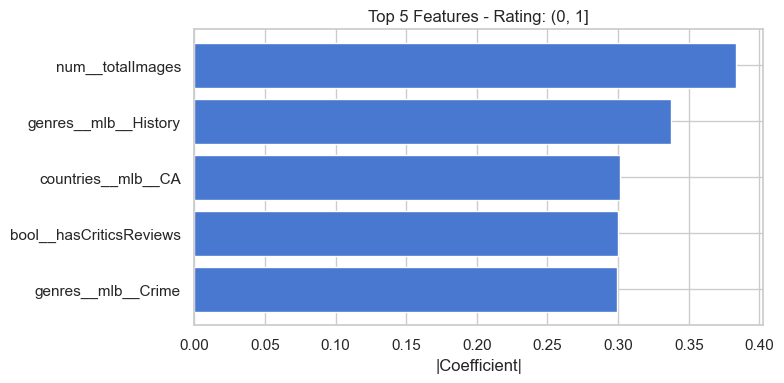

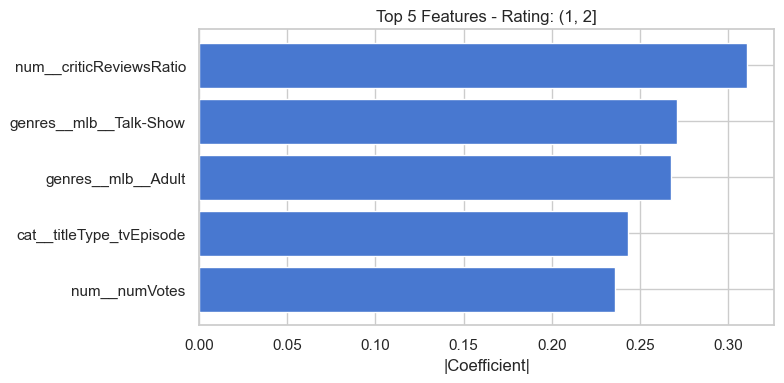

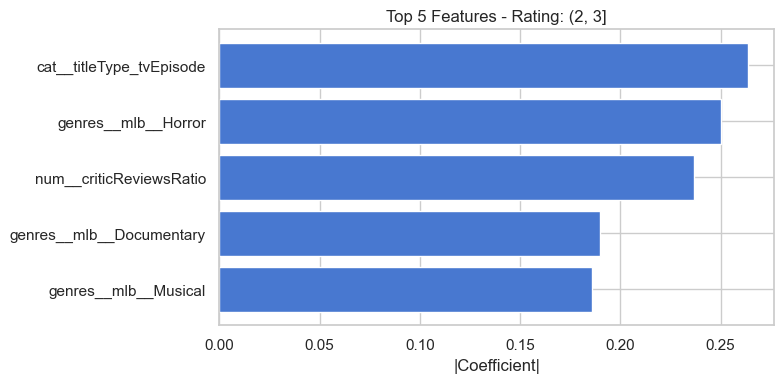

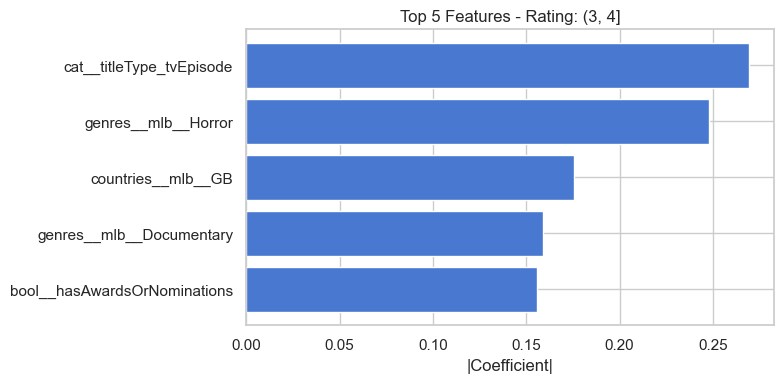

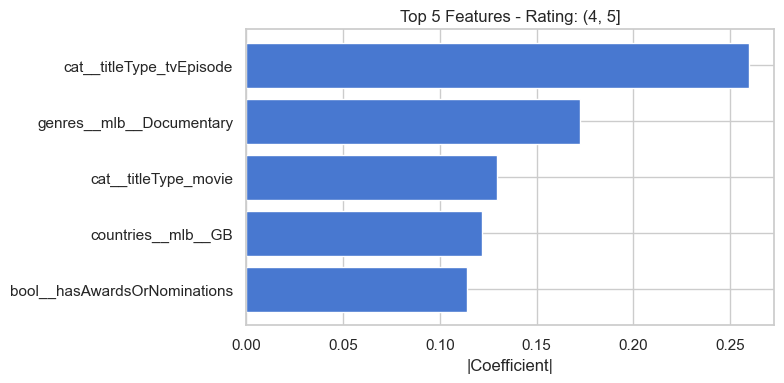

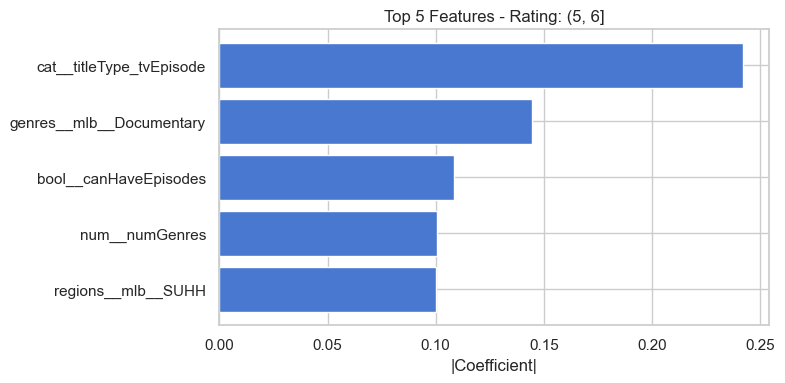

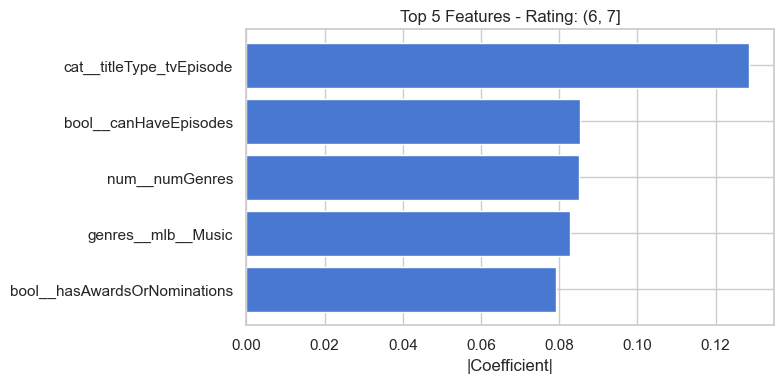

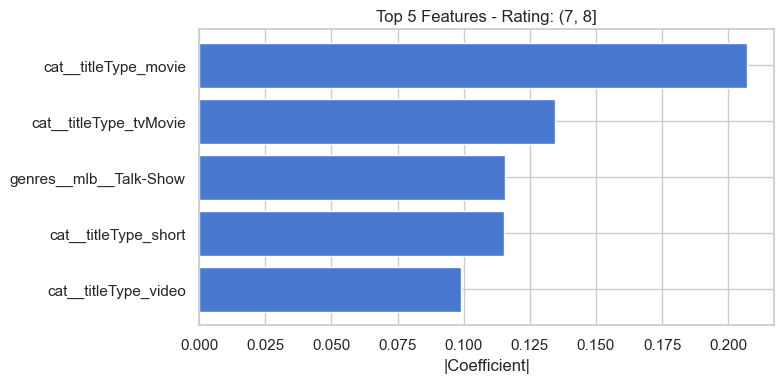

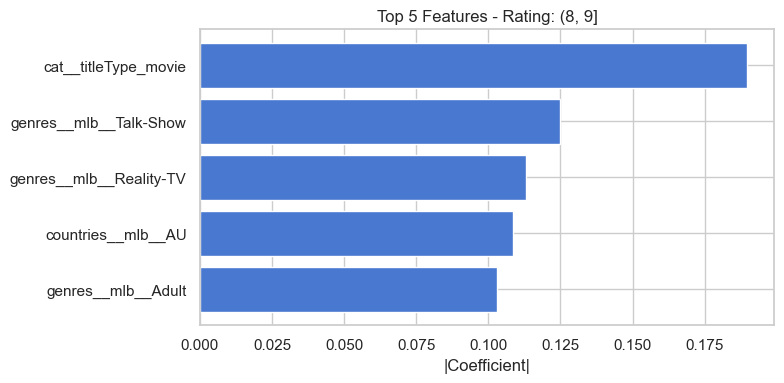

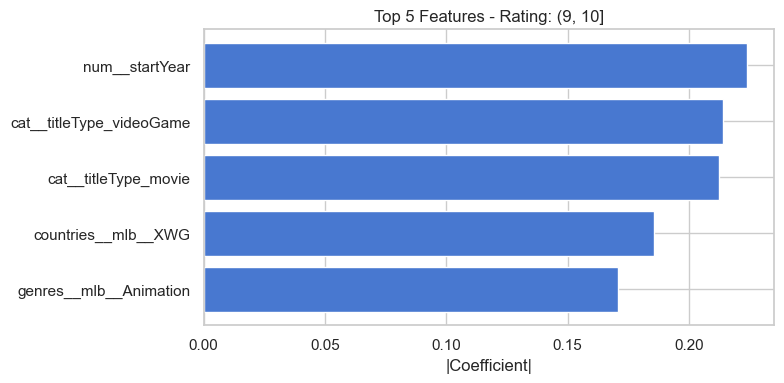

In [84]:
# Top 5 features for each rating class
class_names = svm_clf.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)
    sorted_idx = np.argsort(importance)[::-1][:5] 
    
    top_features = feature_names[sorted_idx]
    top_importance = importance[sorted_idx]
    
    plt.figure(figsize=(8, 4))
    plt.barh(range(len(top_features)), top_importance)
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('|Coefficient|')
    plt.title(f'Top 5 Features - Rating: {class_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [85]:
print("------TOP 10 MOST IMPORTANT FEATURES BY RATING CLASS (LinearSVC)------")

#class_names = svm_clf.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)  # Use absolute values for sorting
    sorted_idx = np.argsort(importance)[::-1][:10]  
    
    top_features = feature_names[sorted_idx]
    top_importance = coef[sorted_idx]  # But use actual coefficient values for display (pos or neg)

    print(f"\nRATING CLASS: {class_name}")
    print("-" * 50)
    
    for rank, (feature, imp) in enumerate(zip(top_features, top_importance), 1):
        print(f"{rank:2d}. {feature:<40} | Coef: {imp:.4f}")
    
    print()

------TOP 10 MOST IMPORTANT FEATURES BY RATING CLASS (LinearSVC)------

RATING CLASS: (0, 1]
--------------------------------------------------
 1. num__totalImages                         | Coef: -0.3835
 2. genres__mlb__History                     | Coef: -0.3376
 3. countries__mlb__CA                       | Coef: -0.3014
 4. bool__hasCriticsReviews                  | Coef: -0.3001
 5. genres__mlb__Crime                       | Coef: -0.2993
 6. genres__mlb__Adult                       | Coef: -0.2943
 7. genres__mlb__Horror                      | Coef: 0.2860
 8. num__criticReviewsRatio                  | Coef: -0.2717
 9. genres__mlb__Sport                       | Coef: -0.2690
10. bool__moreDirectorsCredits               | Coef: 0.2634


RATING CLASS: (1, 2]
--------------------------------------------------
 1. num__criticReviewsRatio                  | Coef: -0.3105
 2. genres__mlb__Talk-Show                   | Coef: 0.2712
 3. genres__mlb__Adult                       | Coef: 

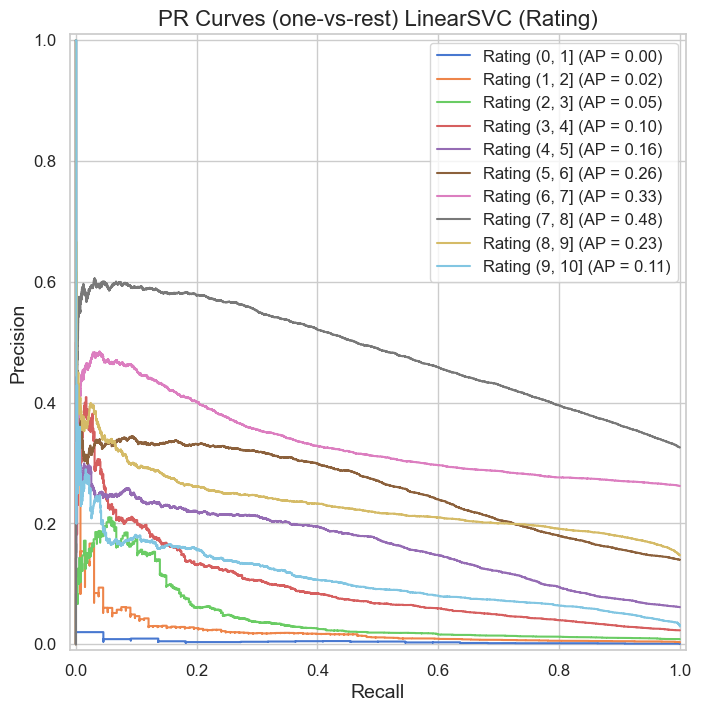

Macro average PR AUC: 0.175


In [91]:
class_labels = linearsvc_rating_model.classes_
y_score = linearsvc_rating_model.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) LinearSVC (Rating)", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

COMMENT

Wrt to the Logistic Regression Model, it achieves a higher macro F1 (0.158 vs 0.145) but a lower accuracy (0.27 vs 0.388).

Indeed we also see that the F1 for the best performing classes has decreased, in favor of better performances for classes with lower support (they're still bad though): the decrease in accuracy is linked to the fact that the model actually tries to predict these lower support classes, rather than focusing merely on the central classes. We see a notable increase for (3,4] and (9,10] (F1 0.113 vs 0.04, 0.145 vs 0.046).

Middle classes are still mostly confused with the most popular (7,8], but this now isn't true for the latter: its misclassification span the different classes. 

The most important feature is the titleType tvEpisode: it is at n.1 with negative values for classes from (2,3] to (5,6] with negative values. Classes (7,8] and (8,9] both have movie at n. 1, w/ negative values, which might explain why the latter is mostly classified as the prior class, which can count on the highest support.

*negative coeff: higher value of feat, less prob for class

PR AUC is slightly worse than Logistic Regression (0.175 vs 0.193)

## Non-linear SVM
Very slow: we only test one kernel, RBF, and test each combination with stratified hold-out.  
P.S.: even like that, 9 + 1 fits took almost 10 hours

In [65]:
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1]
    # class_weight: None by default
}

In [67]:
pipeline_rbf = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [94]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf = GridSearchCV(
    pipeline_rbf,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf.fit(df_train, y_train_rating)

print(f"Best score: {grid_search_rbf.best_score_:.3f}; vs train score: {grid_search_rbf.best_estimator_.score(df_train, y_train_rating):.3f}")
print(f"Best parameters: {grid_search_rbf.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.6s
[Pipeline] .............. (step 2 of 2) Processing clf, total=235.5min
Best score: 0.265; vs train score: 0.723
Best parameters: {'clf__C': 10, 'clf__gamma': 0.1}


ADDEDUM: let's run the same grid search, but keeping class_weight = 'balanced' fixed. 

In [20]:
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1],
    'clf__class_weight': ['balanced']
}

In [23]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf_balanced = GridSearchCV(
    pipeline_rbf,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf_balanced.fit(df_train, y_train_rating)

print(f"Best score: {grid_search_rbf_balanced.best_score_:.3f}; vs train score: {grid_search_rbf_balanced.best_estimator_.score(df_train, y_train_rating):.3f}")
print(f"Best parameters: {grid_search_rbf_balanced.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits
Best score: 0.241; vs train score: 0.641
Best parameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__gamma': 0.1}


Let's save the best among the two models: the one with unbalanced classes.

In [95]:
svm_rbf_rating_model = grid_search_rbf.best_estimator_
joblib.dump(svm_rbf_rating_model, data_dir/"svm_rbf_rating_model.pkl")

['..\\..\\results\\svm_rbf_rating_model.pkl']

In [96]:
y_pred_rating_rbf = svm_rbf_rating_model.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating_rbf, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000        22
      (1, 2]      0.415     0.128     0.195       133
      (2, 3]      0.186     0.051     0.080       374
      (3, 4]      0.245     0.120     0.161      1035
      (4, 5]      0.303     0.214     0.251      2750
      (5, 6]      0.355     0.322     0.338      6270
      (6, 7]      0.418     0.405     0.412     11750
      (7, 8]      0.481     0.675     0.561     14613
      (8, 9]      0.402     0.255     0.312      6591
     (9, 10]      0.498     0.180     0.265      1319

    accuracy                          0.431     44857
   macro avg      0.330     0.235     0.257     44857
weighted avg      0.416     0.431     0.412     44857



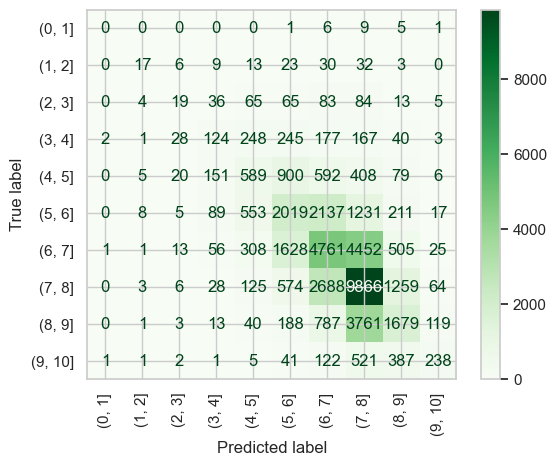

In [97]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating_rbf, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

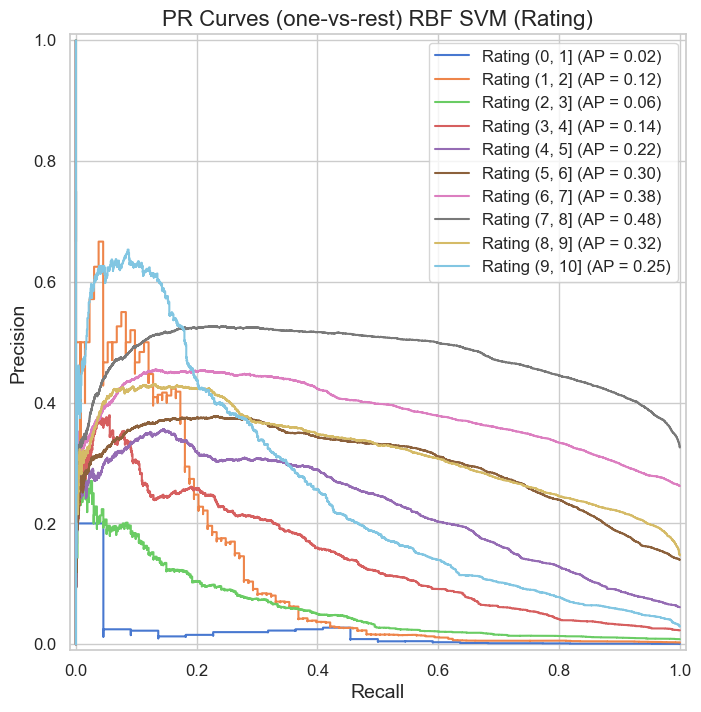

Macro average PR AUC: 0.231


In [99]:
class_labels = svm_rbf_rating_model.classes_
y_score = svm_rbf_rating_model.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) RBF SVM (Rating)", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

In [100]:
# N. of Support Vectors 
n_support_vectors = svm_rbf_rating_model.named_steps['clf'].n_support_
print(f"Number of Support Vectors for each class: {n_support_vectors}")

Number of Support Vectors for each class: [   66   325   808  2404  6269 14789 26364 29134 15039  2834]


COMMENT

The SVM w/ RBF kernel outperforms the other 2 models in terms of both accuracy (0.431) and macro F1 (0.257).

All classes have better performances (except (0,1], which has too small of a support). Notable improvement for [1,2) (F1 0 and 0.02, now 0.195) and (8,9] (from 0.08 and 0.072 to 0.312): it is still mostly classified as (7,8], but at least now it's the 2nd choice.

Middle classes (from 5 to 9): confusion mostly among neighboring classes.

# TitleType

## Pre-Processing

In [89]:
# Overwrite
df_train = train.copy()
df_test = test.copy()

In [90]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [91]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwards', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [92]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [93]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [94]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

## Dummy (baseline)

In [107]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(df_train, y_train_titleType)  
dummy_predictions = dummy_clf.predict(df_test)

print(classification_report(y_test_titleType, dummy_predictions))


              precision    recall  f1-score   support

       movie       0.24      0.25      0.25     11045
       short       0.11      0.10      0.11      4930
   tvEpisode       0.48      0.48      0.48     21234
tvMiniSeries       0.01      0.01      0.01       491
     tvMovie       0.05      0.05      0.05      1861
    tvSeries       0.07      0.06      0.07      2820
     tvShort       0.02      0.01      0.01        88
   tvSpecial       0.00      0.00      0.00       327
       video       0.03      0.03      0.03      1535
   videoGame       0.02      0.02      0.02       526

    accuracy                           0.31     44857
   macro avg       0.10      0.10      0.10     44857
weighted avg       0.30      0.31      0.31     44857



## LinearSVC

In [108]:
param_grid = [
    # L1 and L2 penalty (only with squared_hinge loss)
    {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l1', 'l2'],
        'clf__loss': ['squared_hinge'],
        #'clf__dual': [False],  # the ideal value for dual will be automatically set → default auto
        'clf__max_iter': [5000],
        'clf__class_weight': [None, 'balanced']
    },
    # L2 penalty with hinge loss (dual=True automatically)
    {
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__loss': ['hinge'],
        'clf__max_iter': [5000],
        'clf__class_weight': [None, 'balanced']
    },
]

In [111]:
pipeline_linearsvc_titleType = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LinearSVC(random_state=42, max_iter=5000))
], verbose=True)

In [113]:
grid_search = GridSearchCV(
    pipeline_linearsvc_titleType,
    param_grid=param_grid,
    cv=5,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(df_train, y_train_titleType)

print(f"Best score: {grid_search.best_score_:.3f}; vs train score: {grid_search.best_estimator_.score(df_train, y_train_titleType):.3f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.6s


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[Pipeline] ............... (step 2 of 2) Processing clf, total= 4.5min
Best score: 0.646; vs train score: 0.891
Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__loss': 'squared_hinge', 'clf__max_iter': 5000, 'clf__penalty': 'l1'}


In [114]:
linearsvc_titleType_params = grid_search.best_params_
linearsvc_titleType_model = grid_search.best_estimator_
joblib.dump(linearsvc_titleType_model, data_dir/"linearsvc_titleType_model.pkl")

['..\\..\\results\\linearsvc_titleType_model.pkl']

In [115]:
y_pred_titleType = linearsvc_titleType_model.predict(df_test)
print(classification_report(y_test_titleType, y_pred_titleType, digits=3))

              precision    recall  f1-score   support

       movie      0.911     0.876     0.893     11045
       short      0.913     0.929     0.921      4930
   tvEpisode      0.976     0.966     0.971     21234
tvMiniSeries      0.619     0.621     0.620       491
     tvMovie      0.467     0.455     0.461      1861
    tvSeries      0.934     0.934     0.934      2820
     tvShort      0.117     0.193     0.146        88
   tvSpecial      0.237     0.697     0.354       327
       video      0.593     0.407     0.482      1535
   videoGame      0.486     0.861     0.621       526

    accuracy                          0.889     44857
   macro avg      0.625     0.694     0.640     44857
weighted avg      0.899     0.889     0.892     44857



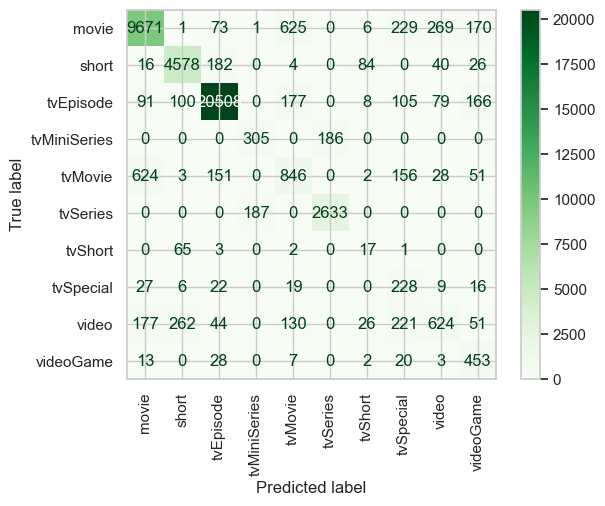

In [116]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_titleType, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

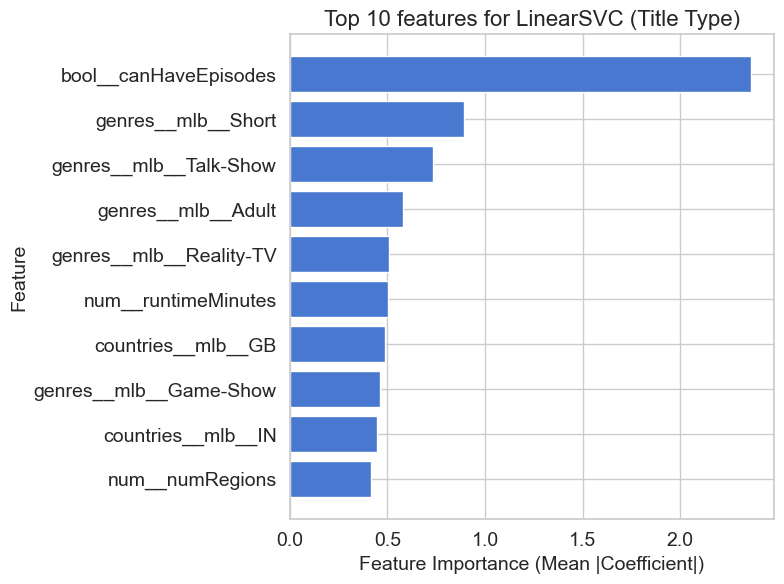

In [117]:
# Get feature importance from LinearSVC coefficients
linearsvc_clf_titleType = linearsvc_titleType_model.named_steps["clf"]
preprocessor = linearsvc_titleType_model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

#coefs: weight for the feat (wk+b)
coefs = linearsvc_clf_titleType.coef_ #one set for class

#feature importance = mean absolute coefficient across all classes
importance = np.mean(np.abs(coefs), axis=0)

sorted_idx = np.argsort(importance)[::-1] #sort by importance
top_n = 10 
top_features = feature_names[sorted_idx[:top_n]]
top_importances = importance[sorted_idx[:top_n]]

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance (Mean |Coefficient|)", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Top 10 features for LinearSVC (Title Type)", fontsize=16)
plt.tight_layout()
plt.show()

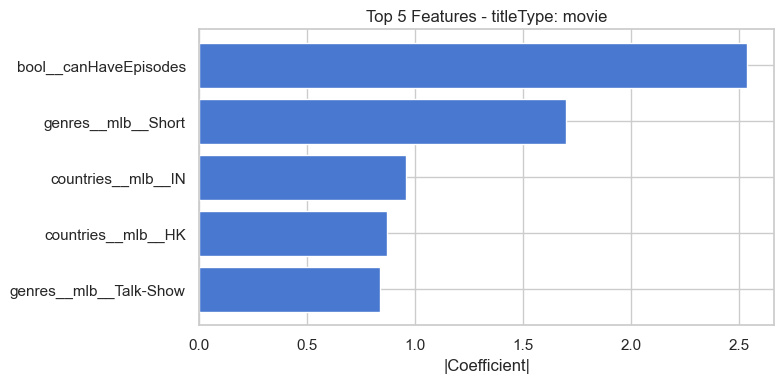

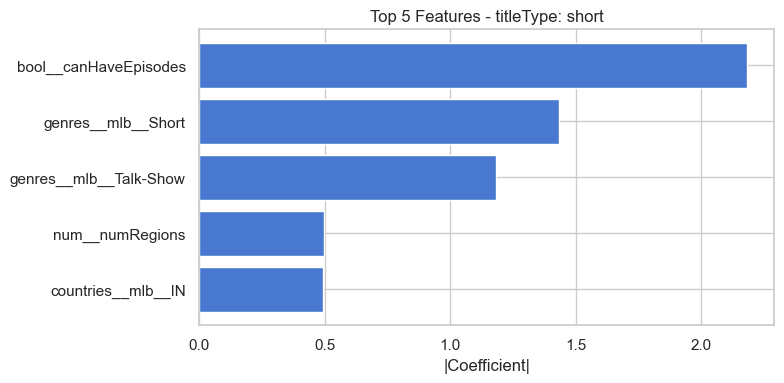

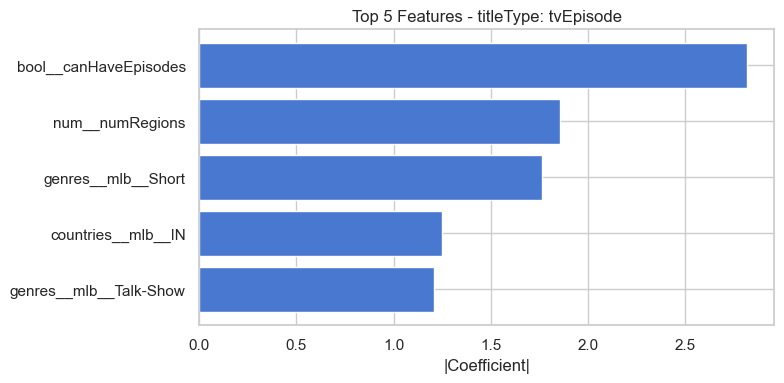

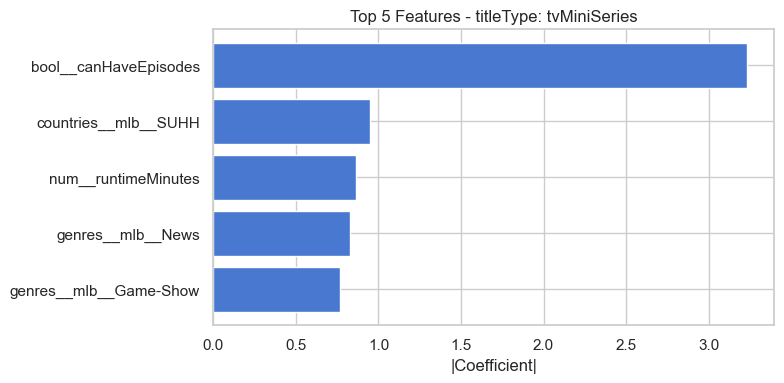

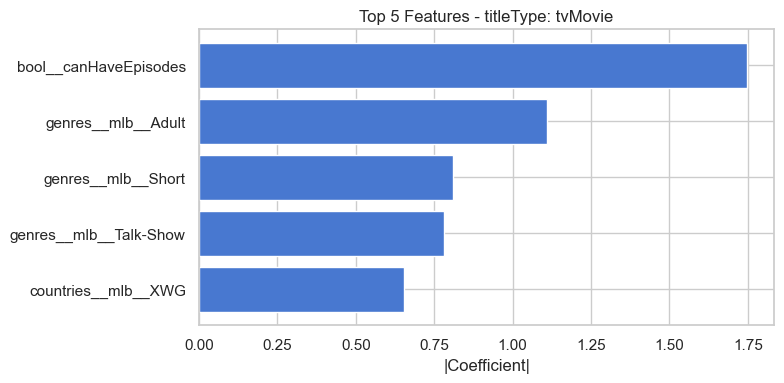

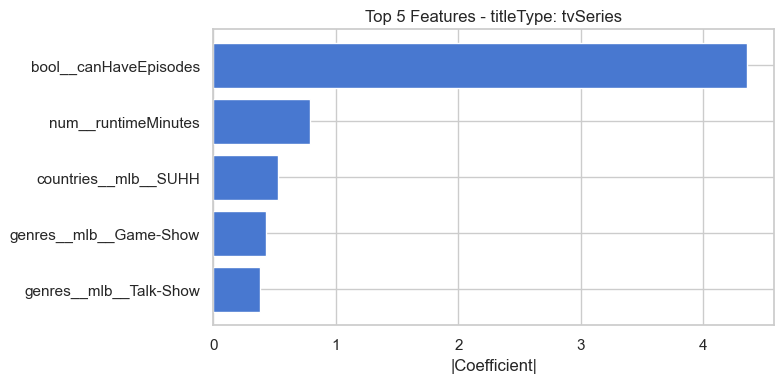

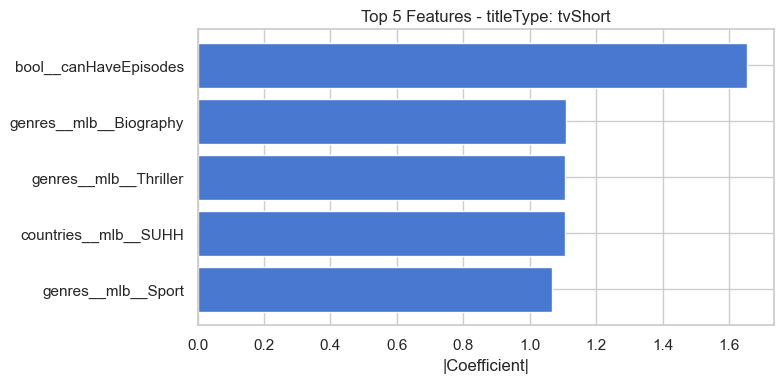

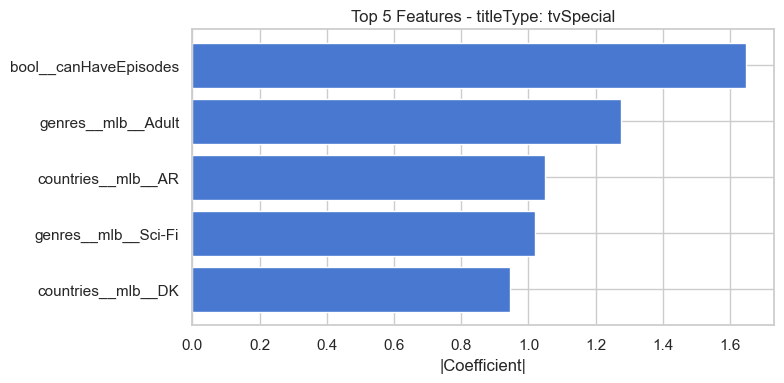

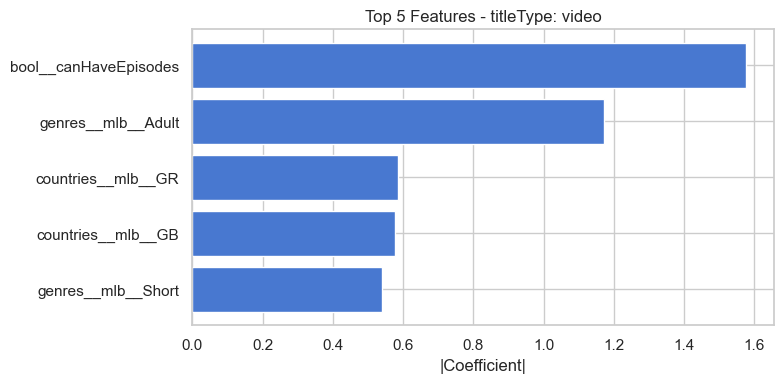

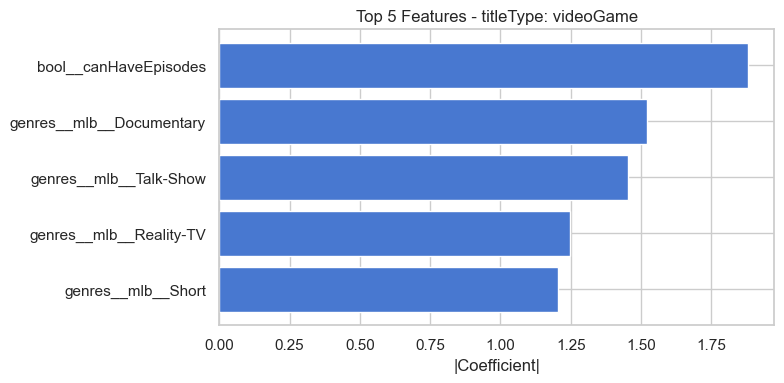

In [118]:
# Top 5 features for each titleType class
class_names = linearsvc_clf_titleType.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)
    sorted_idx = np.argsort(importance)[::-1][:5] 
    
    top_features = feature_names[sorted_idx]
    top_importance = importance[sorted_idx]
    
    plt.figure(figsize=(8, 4))
    plt.barh(range(len(top_features)), top_importance)
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('|Coefficient|')
    plt.title(f'Top 5 Features - titleType: {class_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [119]:
print("------TOP 10 MOST IMPORTANT FEATURES BY TITLE TYPE (LinearSVC)------")

#class_names = svm_clf.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)  # Use absolute values for sorting
    sorted_idx = np.argsort(importance)[::-1][:10]  
    
    top_features = feature_names[sorted_idx]
    top_importance = coef[sorted_idx]  # But use actual coefficient values for display (pos or neg)

    print(f"\nTITLE TYPE: {class_name}")
    print("-" * 50)
    
    for rank, (feature, imp) in enumerate(zip(top_features, top_importance), 1):
        print(f"{rank:2d}. {feature:<40} | Coef: {imp:.4f}")
    
    print()

------TOP 10 MOST IMPORTANT FEATURES BY TITLE TYPE (LinearSVC)------

TITLE TYPE: movie
--------------------------------------------------
 1. bool__canHaveEpisodes                    | Coef: -2.5344
 2. genres__mlb__Short                       | Coef: -1.6999
 3. countries__mlb__IN                       | Coef: 0.9574
 4. countries__mlb__HK                       | Coef: 0.8716
 5. genres__mlb__Talk-Show                   | Coef: -0.8359
 6. countries__mlb__BR                       | Coef: 0.7951
 7. num__runtimeMinutes                      | Coef: 0.7701
 8. countries__mlb__TR                       | Coef: 0.6819
 9. countries__mlb__ES                       | Coef: 0.6782
10. countries__mlb__GB                       | Coef: -0.5703


TITLE TYPE: short
--------------------------------------------------
 1. bool__canHaveEpisodes                    | Coef: -2.1804
 2. genres__mlb__Short                       | Coef: 1.4313
 3. genres__mlb__Talk-Show                   | Coef: -1.1815
 4. 

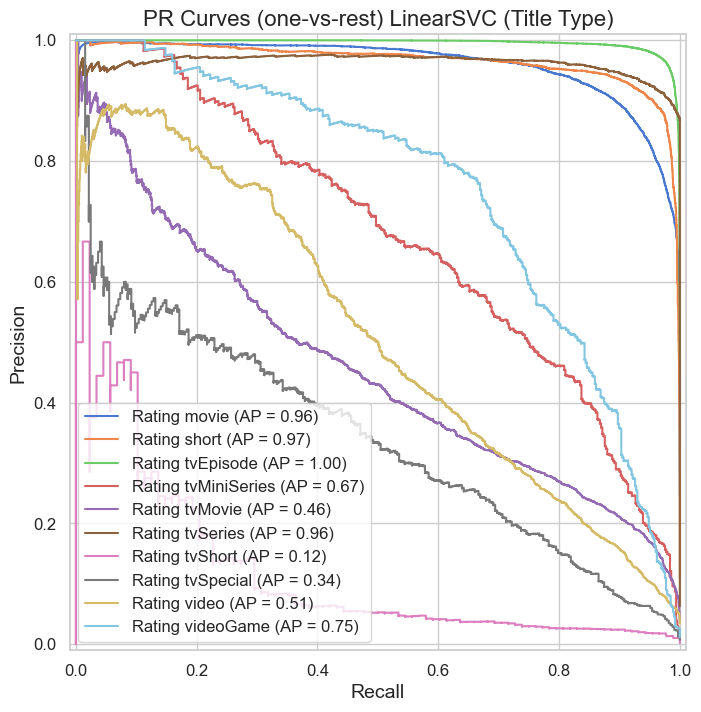

Macro average PR AUC: 0.674


In [120]:
class_labels = linearsvc_titleType_model.classes_
y_score = linearsvc_titleType_model.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) LinearSVC (Title Type)", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

COMMENT

Logistic Regression achieves better accuracy and macro F1 by a small margin (acc: 0.908 vs 0.889; macro F1 0.649 vs 0.640).

Performances for all classes decrease slightly, except for tvMiniSeries, tvMovie and tvShort (big jump to 0.146 bc this models predicts it more often. Mostly classified as shorts, then video, and only then tvShort). Big dip in videogame's precision. 

The overall most important features are the same (canHaveEpisodes, genre Short and genre Talk-Show) but now only canHaveEpisodes really stand out, Short has similar values to the rest of the top feats.

Incredibly, the most important feature for short is now canHaveEpisodes, which quite an 'advantage' (canHaveEpisodes coef: -2.1804, vs genre Short 1.4313). For tvShort it only comes at number 9.

## Non-linear SVM

In [46]:
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1]
}

In [47]:
pipeline_rbf = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [48]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf = GridSearchCV(
    pipeline_rbf,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf.fit(df_train, y_train_titleType)

print(f"Best score: {grid_search_rbf.best_score_:.3f}; vs train score: {grid_search_rbf.best_estimator_.score(df_train, y_train_titleType):.3f}")
print(f"Best parameters: {grid_search_rbf.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits


KeyboardInterrupt: 

(accidentally lost output)

Fitting 1 folds for each of 9 candidates, totalling 9 fits

Best score: 0.746; vs train score: 0.976

Best parameters: {'clf__C': 10, 'clf__gamma': 'scale'}

ADDEDUM: let's run the same grid search, but keeping class_weight = 'balanced' fixed. 

In [31]:
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1],
    'clf__class_weight': ['balanced']
}

In [32]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf_balanced = GridSearchCV(
    pipeline_rbf,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf_balanced.fit(df_train, y_train_titleType)

print(f"Best score: {grid_search_rbf_balanced.best_score_:.3f}; vs train score: {grid_search_rbf_balanced.best_estimator_.score(df_train, y_train_titleType):.3f}")
print(f"Best parameters: {grid_search_rbf_balanced.best_params_}")

Fitting 1 folds for each of 9 candidates, totalling 9 fits
Best score: 0.734; vs train score: 0.978
Best parameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__gamma': 0.1}


Again, the best model has class_weight = None.

In [123]:
svm_rbf_titleType_params = grid_search_rbf.best_params_
print(f"Non-linear SVM's params: {svm_rbf_titleType_params}")
svm_rbf_titleType_model = grid_search_rbf.best_estimator_
joblib.dump(svm_rbf_titleType_model, data_dir/"svm_rbf_titleType_model.pkl")

Non-linear SVM's params: {'clf__C': 10, 'clf__gamma': 'scale'}


['..\\..\\results\\svm_rbf_titleType_model.pkl']

In [124]:
y_pred_titleType_rbf = svm_rbf_titleType_model.predict(df_test)
print(classification_report(y_test_titleType, y_pred_titleType_rbf, digits=3))

              precision    recall  f1-score   support

       movie      0.915     0.959     0.937     11045
       short      0.943     0.976     0.959      4930
   tvEpisode      0.986     0.994     0.990     21234
tvMiniSeries      0.729     0.597     0.656       491
     tvMovie      0.694     0.555     0.616      1861
    tvSeries      0.932     0.961     0.946      2820
     tvShort      0.750     0.136     0.231        88
   tvSpecial      0.629     0.550     0.587       327
       video      0.756     0.582     0.658      1535
   videoGame      0.908     0.861     0.884       526

    accuracy                          0.938     44857
   macro avg      0.824     0.717     0.746     44857
weighted avg      0.934     0.938     0.934     44857



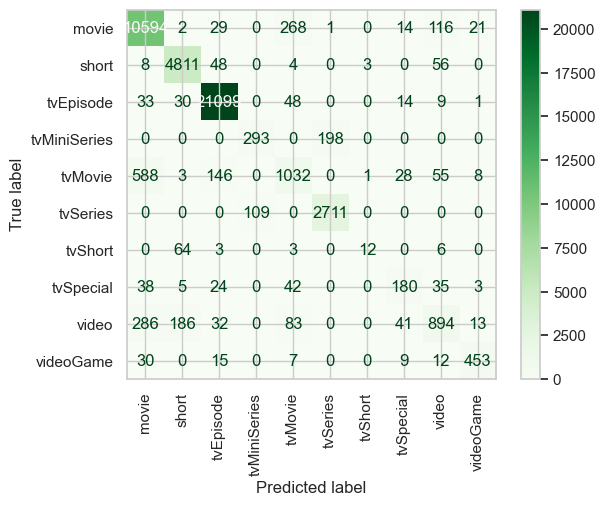

In [125]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_titleType_rbf, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

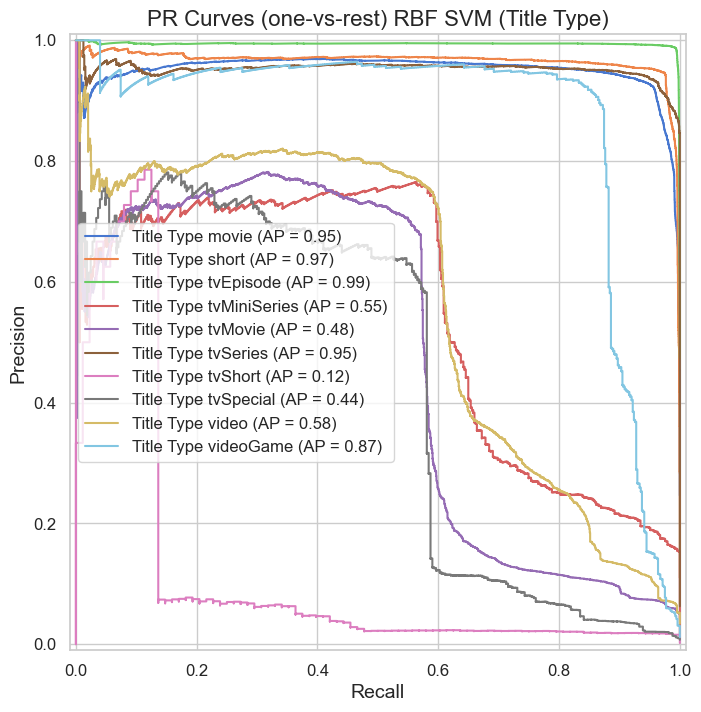

Macro average PR AUC: 0.689


In [126]:
class_labels = svm_rbf_titleType_model.classes_
y_score = svm_rbf_titleType_model.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Title Type {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) RBF SVM (Title Type)", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

In [127]:
# N. of Support Vectors 
n_support_vectors = svm_rbf_titleType_model.named_steps['clf'].n_support_
print(f"Number of Support Vectors for each class: {n_support_vectors}")

Number of Support Vectors for each class: [6658 2518 2794  957 3351 2197  177  702 2539  629]


COMMENTS

Best performing model thus far, both in terms of accuracy (LR 0.908 vs 0.938) and macro F1 (LR 0.649 vs 0.746).

All classes yield better performances. tvEpisode now achieve 0.99 F1. Great improvement for videogame (f1 0.884), tvShort (0.231; not predicted often, but w/ impressing precision), video 


(expand comment on PR curves if needed)
PR AUC: actually lower than logistic regression (0.689 vs 0.705).
This discrepancy PR AUC- performances is linked to the position of our decision threshold: except for the best performing classes, the precision dips for a recall >0.60.

# Checking overfitting
NB: run the correct cells to prep df_train for the specific task (rating vs titleType). 

## Rating

In [17]:
linearsvc_rating_model = joblib.load(data_dir / "linearsvc_rating_model.pkl")
print("LinearSVC model for rating loaded successfully!")

LinearSVC model for rating loaded successfully!


In [18]:
y_pred_rating_train = linearsvc_rating_model.predict(df_train)
print(classification_report(y_train_rating, y_pred_rating_train, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.005     0.833     0.010        66
      (1, 2]      0.014     0.296     0.026       341
      (2, 3]      0.032     0.153     0.053       808
      (3, 4]      0.093     0.189     0.125      2408
      (4, 5]      0.196     0.236     0.214      6336
      (5, 6]      0.326     0.232     0.271     15055
      (6, 7]      0.421     0.153     0.224     27276
      (7, 8]      0.485     0.509     0.497     33937
      (8, 9]      0.278     0.043     0.075     15475
     (9, 10]      0.090     0.332     0.142      2962

    accuracy                          0.275    104664
   macro avg      0.194     0.298     0.164    104664
weighted avg      0.372     0.275     0.290    104664



LINEAR SVM RATING

→ Train macro F1: 0.164

→ Mean validation macro F1: 0.158

→ Test macro F1: 0.158

No overfitting.

In [19]:
svm_rbf_rating_model = joblib.load(data_dir / "svm_rbf_rating_model.pkl")
print("SVM RBF model for rating loaded successfully!")

SVM RBF model for rating loaded successfully!


In [20]:
y_pred_rating_train = svm_rbf_rating_model.predict(df_train)
print(classification_report(y_train_rating, y_pred_rating_train, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.846     0.500     0.629        66
      (1, 2]      0.924     0.572     0.707       341
      (2, 3]      0.967     0.583     0.727       808
      (3, 4]      0.913     0.613     0.733      2408
      (4, 5]      0.878     0.668     0.759      6336
      (5, 6]      0.817     0.708     0.759     15055
      (6, 7]      0.758     0.703     0.729     27276
      (7, 8]      0.640     0.890     0.744     33937
      (8, 9]      0.759     0.512     0.611     15475
     (9, 10]      0.867     0.440     0.584      2962

    accuracy                          0.723    104664
   macro avg      0.837     0.619     0.698    104664
weighted avg      0.744     0.723     0.719    104664



NON-LINEAR SVM RATING

→ Test macro F1: 0.265

→ Mean validation macro F1: 0.257

→ Train macro F1: 0.698 → OVERFITTING on all classes.

## TitleType

In [27]:
linearsvc_titleType_model = joblib.load(data_dir / "linearsvc_titleType_model.pkl")
print("LinearSVC model for titleType loaded successfully!")

LinearSVC model for titleType loaded successfully!


In [28]:
y_pred_titleType_train = linearsvc_titleType_model.predict(df_train)
print(classification_report(y_train_titleType, y_pred_titleType_train, digits=3))

              precision    recall  f1-score   support

       movie      0.915     0.871     0.893     26053
       short      0.906     0.932     0.919     11448
   tvEpisode      0.977     0.965     0.971     49588
tvMiniSeries      0.669     0.672     0.670      1128
     tvMovie      0.475     0.480     0.477      4195
    tvSeries      0.942     0.941     0.942      6386
     tvShort      0.126     0.282     0.174       181
   tvSpecial      0.258     0.692     0.376       822
       video      0.593     0.417     0.490      3612
   videoGame      0.494     0.875     0.632      1251

    accuracy                          0.891    104664
   macro avg      0.636     0.713     0.654    104664
weighted avg      0.902     0.891     0.894    104664



LINEAR SVM 

→ Train macro F1: 0.654

→ Mean validation macro F1: 0.646

→ Test macro F1: 0.640

NO OVERFITTING


In [29]:
svm_rbf_titleType_model = joblib.load(data_dir / "svm_rbf_titleType_model.pkl")
print("SVM RBF model for titleType loaded successfully!")

SVM RBF model for titleType loaded successfully!


In [30]:
y_pred_titleType_train = svm_rbf_titleType_model.predict(df_train)
print(classification_report(y_train_titleType, y_pred_titleType_train, digits=3))

              precision    recall  f1-score   support

       movie      0.966     0.984     0.975     26053
       short      0.967     0.995     0.981     11448
   tvEpisode      0.994     0.998     0.996     49588
tvMiniSeries      0.966     0.926     0.945      1128
     tvMovie      0.897     0.810     0.851      4195
    tvSeries      0.987     0.994     0.991      6386
     tvShort      0.989     0.481     0.647       181
   tvSpecial      0.877     0.807     0.840       822
       video      0.898     0.800     0.846      3612
   videoGame      0.979     0.984     0.982      1251

    accuracy                          0.976    104664
   macro avg      0.952     0.878     0.905    104664
weighted avg      0.975     0.976     0.975    104664



NON-LINEAR SVM 

→ Train macro F1: 0.905

→ Mean validation macro F1: 0.746

→ Test macro F1: 0.746

OVERFITTING


# Trying to mitigate overfitting for SVM w/ RBF

## Rating

Let's first see if our model w/ balanced classes was overfitted.

In [68]:
pipeline_rbf = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [70]:
pipeline_rbf.set_params(clf__C=10, clf__class_weight='balanced', clf__gamma=0.1)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
pipeline_rbf.fit(df_train, y_train_rating)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
# predict on training set
y_train_pred_rating = pipeline_rbf.predict(df_train)
print(classification_report(y_train_rating, y_train_pred_rating, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.199     1.000     0.332        66
      (1, 2]      0.389     0.991     0.558       341
      (2, 3]      0.435     0.959     0.598       808
      (3, 4]      0.485     0.934     0.638      2408
      (4, 5]      0.613     0.831     0.706      6336
      (5, 6]      0.700     0.707     0.704     15055
      (6, 7]      0.779     0.553     0.647     27276
      (7, 8]      0.756     0.578     0.655     33937
      (8, 9]      0.525     0.667     0.588     15475
     (9, 10]      0.332     0.935     0.490      2962

    accuracy                          0.641    104664
   macro avg      0.521     0.815     0.592    104664
weighted avg      0.689     0.641     0.647    104664



→ TRAIN MACRO F1: 0.592
→ VALIDATION MACRO F1: 0.241
Slightly less, but still overfitted.

Let's rerun the GridSearch, this time forcing the C and gamma values to be smaller.
NB for the future: just pickle the gridSearch next time.

In [79]:
param_grid = {
    'clf__C': [0.1, 1],
    'clf__gamma': ['scale', 0.01],
    'clf__class_weight': ['balanced', None]
}

In [80]:
pipeline_rbf = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [81]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf = GridSearchCV(
    pipeline_rbf,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index = grid_search_rbf.best_index_
train_macro_f1 = grid_search_rbf.cv_results_['mean_train_f1_macro'][best_index]

print(f"Validation macro F1: {grid_search_rbf.best_score_:.3f}; vs macro F1 on train: {train_macro_f1:.3f}")
print(f"Best parameters: {grid_search_rbf.best_params_}")

Fitting 1 folds for each of 8 candidates, totalling 8 fits
BEST MODEL:
Validation macro F1: 0.206; vs macro F1 on train: 0.316
Best parameters: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale'}


In [83]:
cv_results = pd.DataFrame(grid_search_rbf.cv_results_)
cv_results['overfitting_gap'] = cv_results['mean_train_f1_macro'] - cv_results['mean_test_f1_macro']
display(cv_results[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.207928,0.180667,0.027261
1,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.148405,0.141366,0.007039
2,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.115472,0.111690,0.003781
3,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.092521,0.091449,0.001073
4,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.316417,0.205656,0.110761
5,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.190939,0.175114,0.015825
6,"{'clf__C': 1, 'clf__class_weight': None, 'clf_...",0.218715,0.175902,0.042813
7,"{'clf__C': 1, 'clf__class_weight': None, 'clf_...",0.116118,0.113668,0.002450


We actually choose the best estimator, as the overfitting is not too bad and the other classifiers have significantly lower performances.

In [84]:
# save the results and best model bc the entire grid is too large
cv_results.to_csv(data_dir/"svm_rating_overfitting_results.csv", index=False)

In [85]:
svm_rating_overfitting = grid_search_rbf.best_estimator_
joblib.dump(svm_rating_overfitting, data_dir/"svm_rating_overfitting_model.pkl")

['..\\..\\results\\svm_rating_overfitting_model.pkl']

In [86]:
y_pred_rating_rbf = svm_rating_overfitting.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating_rbf, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.020     0.500     0.038        22
      (1, 2]      0.047     0.376     0.084       133
      (2, 3]      0.050     0.243     0.083       374
      (3, 4]      0.114     0.322     0.168      1035
      (4, 5]      0.222     0.320     0.262      2750
      (5, 6]      0.338     0.301     0.318      6270
      (6, 7]      0.468     0.196     0.276     11750
      (7, 8]      0.540     0.383     0.448     14613
      (8, 9]      0.285     0.322     0.302      6591
     (9, 10]      0.129     0.607     0.212      1319

    accuracy                          0.314     44857
   macro avg      0.221     0.357     0.219     44857
weighted avg      0.408     0.314     0.334     44857



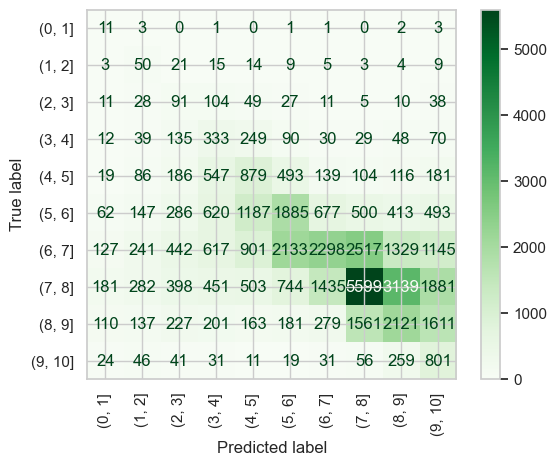

In [87]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating_rbf, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

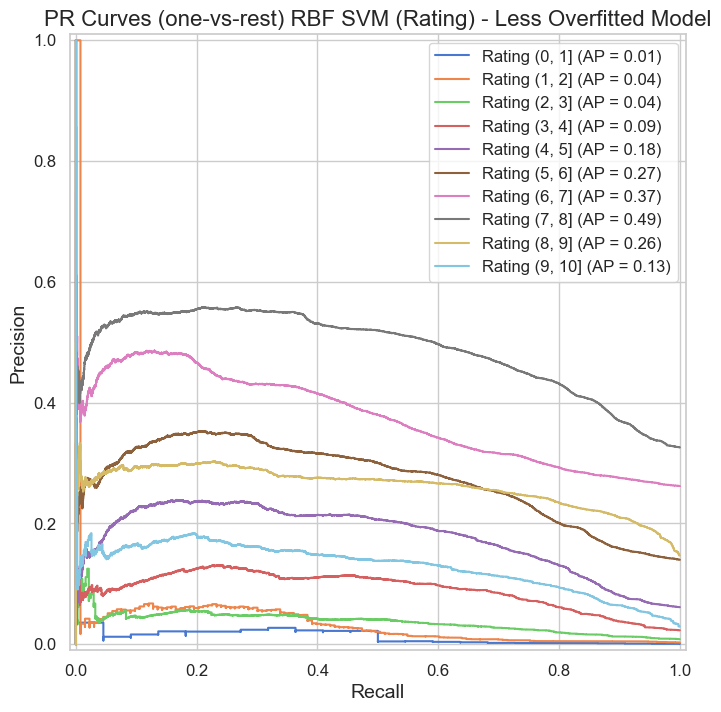

Macro average PR AUC: 0.188


In [88]:
class_labels = svm_rating_overfitting.classes_
y_score = svm_rating_overfitting.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) RBF SVM (Rating) - Less Overfitted Model", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

The overfitted model yielded better performances, also poorer PR AUC.

## TitleType

Let's check if the model w/ balanced class weights is overfitted.

In [95]:
pipeline_rbf_tts = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [96]:
pipeline_rbf_tts.set_params(clf__C=10, clf__class_weight='balanced', clf__gamma=0.1)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
pipeline_rbf_tts.fit(df_train, y_train_titleType)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [98]:
# predict on training set
y_train_pred_tts = pipeline_rbf_tts.predict(df_train)
print(classification_report(y_train_titleType, y_train_pred_tts, digits=3))

              precision    recall  f1-score   support

       movie      0.998     0.949     0.973     26053
       short      0.992     0.985     0.988     11448
   tvEpisode      0.999     0.989     0.994     49588
tvMiniSeries      0.976     0.999     0.987      1128
     tvMovie      0.777     0.972     0.864      4195
    tvSeries      1.000     0.996     0.998      6386
     tvShort      0.834     1.000     0.910       181
   tvSpecial      0.791     1.000     0.883       822
       video      0.836     0.959     0.893      3612
   videoGame      0.982     1.000     0.991      1251

    accuracy                          0.978    104664
   macro avg      0.918     0.985     0.948    104664
weighted avg      0.981     0.978     0.979    104664



→ TRAIN MACRO F1: 0.948
→ VALIDATION MACRO F1: 0.734
even more overfitted


Let's rerun the GridSearch, this time forcing the C and gamma values to be smaller.

In [99]:
param_grid = {
    'clf__C': [0.1, 1],
    'clf__gamma': ['scale', 0.01],
    'clf__class_weight': ['balanced', None]
}

In [100]:
pipeline_rbf_tts = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', SVC(kernel='rbf', random_state=42))
])

In [101]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

grid_search_rbf_tts = GridSearchCV(
    pipeline_rbf_tts,
    param_grid=param_grid,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_rbf_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index = grid_search_rbf_tts.best_index_
train_macro_f1_tts = grid_search_rbf_tts.cv_results_['mean_train_f1_macro'][best_index]

print(f"Validation macro F1: {grid_search_rbf_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_tts:.3f}")
print(f"Best parameters: {grid_search_rbf_tts.best_params_}")

Fitting 1 folds for each of 8 candidates, totalling 8 fits
BEST MODEL:
Validation macro F1: 0.716; vs macro F1 on train: 0.808
Best parameters: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale'}


In [102]:
cv_results_tts = pd.DataFrame(grid_search_rbf_tts.cv_results_)
cv_results_tts['overfitting_gap'] = cv_results_tts['mean_train_f1_macro'] - cv_results_tts['mean_test_f1_macro']
display(cv_results_tts[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.678858,0.653545,0.025313
1,"{'clf__C': 0.1, 'clf__class_weight': 'balanced...",0.608072,0.600692,0.007380
2,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.564143,0.557333,0.006810
3,"{'clf__C': 0.1, 'clf__class_weight': None, 'cl...",0.450102,0.447943,0.002159
4,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.808497,0.716351,0.092146
5,"{'clf__C': 1, 'clf__class_weight': 'balanced',...",0.661184,0.644031,0.017153
6,"{'clf__C': 1, 'clf__class_weight': None, 'clf_...",0.748435,0.710221,0.038214
7,"{'clf__C': 1, 'clf__class_weight': None, 'clf_...",0.620078,0.615480,0.004598


We choose #6 because the gap between the train and validation macro F1 is smaller while the performances are very similar to the best performing model (0.710 vs 0.716).

In [103]:
row_idx = 6  
best_param_tts = cv_results_tts.iloc[row_idx]["params"]
svm_tts_overfitting = grid_search_rbf_tts.estimator.set_params(**best_param_tts)

svm_tts_overfitting.fit(df_train, y_train_titleType)

joblib.dump(svm_tts_overfitting, data_dir/"best_model_row6.joblib")


['..\\..\\results\\best_model_row6.joblib']

In [104]:
y_pred_tts_rbf = svm_tts_overfitting.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tts_rbf, digits=3))

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       movie      0.892     0.972     0.930     11045
       short      0.933     0.974     0.953      4930
   tvEpisode      0.982     0.993     0.988     21234
tvMiniSeries      0.806     0.532     0.640       491
     tvMovie      0.721     0.470     0.569      1861
    tvSeries      0.923     0.978     0.950      2820
     tvShort      0.000     0.000     0.000        88
   tvSpecial      0.629     0.456     0.528       327
       video      0.788     0.494     0.607      1535
   videoGame      0.909     0.819     0.862       526

    accuracy                          0.933     44857
   macro avg      0.758     0.669     0.703     44857
weighted avg      0.926     0.933     0.926     44857



c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


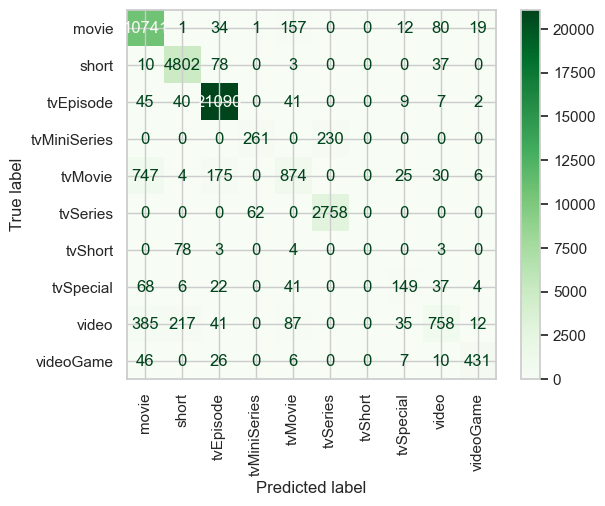

In [105]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_tts_rbf, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

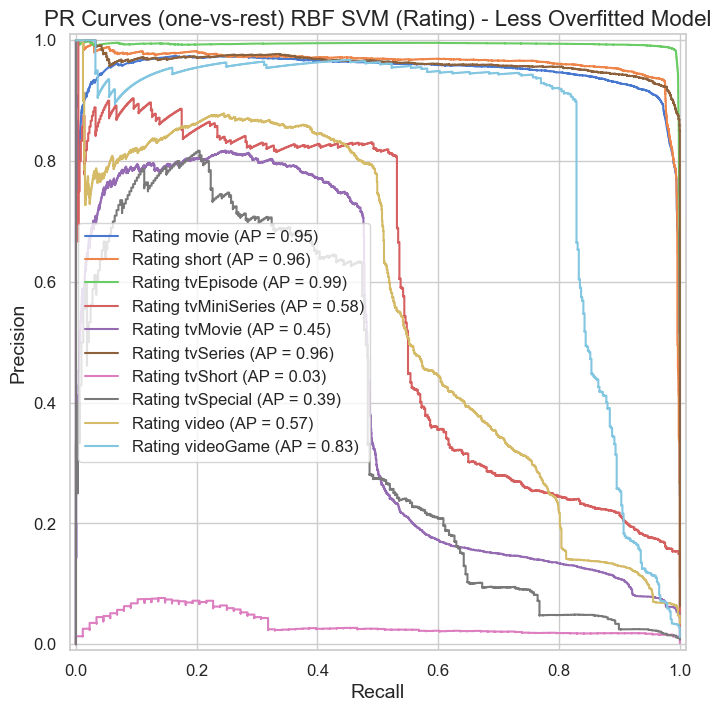

Macro average PR AUC: 0.672


In [106]:
class_labels = svm_tts_overfitting.classes_
y_score = svm_tts_overfitting.decision_function(df_test)

# Convert decision scores to probabilities using softmax
y_score_prob = softmax(y_score, axis=1)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score_prob[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend(fontsize=12)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("PR Curves (one-vs-rest) RBF SVM (Rating) - Less Overfitted Model", fontsize=16)
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score_prob, average='macro'):.3f}")

Again, we end up with slightly poorer results. What jumps to the eye is the 0 R and P for tvShort: it was never predicted, the model aggregated it to shorts. The area under the single PR curves are quite similar; for the mid-performing classes the drop in precision is anticipated at 0.5 recall (vs close to 0.6).